In [1]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, LSTM,
                                     Input, Concatenate, Embedding,
                                     MultiHeadAttention, GlobalAveragePooling1D,
                                     LayerNormalization)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

2026-03-06 20:44:23.414384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772829863.619184      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772829863.671500      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772829864.108012      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772829864.108052      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772829864.108055      24 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"✓ Seeds fixed to {SEED}")

✓ Seeds fixed to 42


## Changes Made to Improve Model Performance

### Problem
The original models gave poor results:
- Baseline: 0.6747
- Attention: 0.5652 (▼ dropped)
- Embedding: 0.5027 (▼ dropped)

### Root Causes
1. **No fixed random seed** — results were not reproducible, model weights initialized differently each run
2. **Dropout too high (0.4)** — was randomly dropping too many neurons, preventing the model from learning
3. **No normalization inside LSTM/Attention** — unstable gradients during training
4. **Too few epochs in Phase 1** — RNN branch didn't converge before fine-tuning started
5. **Learning rate too high in Phase 2** — aggressive fine-tuning caused the model to forget pretrained features

---

### Fixes Applied

| Change | Before | After | Reason |
|---|---|---|---|
| Random seed | Not fixed | `SEED = 42` everywhere | Reproducibility across runs |
| Dropout rate | `0.4` | `0.3` | Was too aggressive, causing underfitting |
| BatchNorm after LSTM | ✗ | ✓ | Stabilizes gradients during RNN training |
| LayerNorm around Attention | ✗ | ✓ | Standard practice, improves attention stability |
| CNN head Dense layers | 1 layer (128) | 2 layers (256 → 128) | More capacity to learn CTG-specific features |
| Merged head Dense units | 128 | 256 → 128 | More capacity in final classification layers |
| Phase 1 epochs | 15 | 25 | More time for RNN branch to converge before fine-tuning |
| Phase 2 learning rate | `1e-4` | `5e-5` | Gentler fine-tuning, prevents forgetting pretrained weights |
| Unfrozen ResNet layers | 30 | 50 | More ResNet layers adapt to CTG-specific visual patterns |
| ModelCheckpoint | ✗ | ✓ | Saves best weights even if final epoch is worse |
| EarlyStopping patience | 10 | 15 | Gives model more time before stopping |
| ReduceLROnPlateau patience | 5 | 7 | Less aggressive LR reduction |
| Embedding output dim | 16 | 32 | Richer learned representations for FHR bins |
| N_BINS (discretization) | 100 | 128 | Finer FHR resolution for embedding lookup |

---

### Architecture Improvements

**LSTM Branch — added BatchNormalization:**
```
LSTM(128) → BatchNorm → Dropout(0.3)
LSTM(128) → BatchNorm → Dropout(0.3)
LSTM(128)
```

**Attention Branch — added LayerNormalization:**
```
LSTM(128, return_seq=True) → BatchNorm → Dropout
LSTM(128, return_seq=True) → BatchNorm → Dropout  
LSTM(128, return_seq=True)
LayerNorm → MultiHeadAttention(heads=4, key_dim=32) → LayerNorm
GlobalAvgPool1D → Dense(128)
```

**Embedding Branch — richer representations:**
```
Embedding(128 bins, 32 dims)   ← was Embedding(100, 16)
LSTM(128) → BatchNorm → Dropout
LSTM(128) → BatchNorm → Dropout
LSTM(128) → Dense(128)
```

**Merged Head — more capacity:**
```
Concatenate([CNN, RNN])
Dense(256, relu) → BatchNorm → Dropout(0.3)
Dense(128, relu) → Dropout(0.2)
Dense(3, softmax)
```

---

### Training Strategy

| | Phase 1 | Phase 2 |
|---|---|---|
| CNN layers | Frozen | Top 50 unfrozen |
| Learning rate | `1e-3` | `5e-5` |
| Batch size | 32 | 16 |
| Max epochs | 25 | 40 |
| Early stopping patience | 15 | 15 |

# Paths

In [3]:
NB1_DIR   = '/kaggle/input/datasets/annn51/mobilenetv2-datasets/processed_data'
MODEL_DIR = '/kaggle/working/models'
PLOTS_DIR = '/kaggle/working/plots'

for d in [MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# SECTION 1 — Load data


In [4]:
#   X_*_seq.npy  → raw signal windows  shape: (n_windows, 600, 2)
#                  channel 0 = FHR (normalized), channel 1 = UC (normalized)
#   X_*_img.npy  → CTG plot images     shape: (n_windows, 224, 224, 3)
#                  each window plotted as blue(FHR)/red(UC) on white background
#   y_*_seq.npy  → integer labels       0=Normal, 1=Suspect, 2=Pathologic

In [5]:
print("Loading data...")
X_tr_seq = np.load(os.path.join(NB1_DIR, 'X_tr_seq.npy'))  # train sequences
X_te_seq = np.load(os.path.join(NB1_DIR, 'X_te_seq.npy'))  # test  sequences
X_va_seq = np.load(os.path.join(NB1_DIR, 'X_va_seq.npy'))  # val   sequences
X_tr_img = np.load(os.path.join(NB1_DIR, 'X_tr_img.npy'))  # train images
X_te_img = np.load(os.path.join(NB1_DIR, 'X_te_img.npy'))  # test  images
X_va_img = np.load(os.path.join(NB1_DIR, 'X_va_img.npy'))  # val   images
y_tr_seq = np.load(os.path.join(NB1_DIR, 'y_tr_seq.npy'))  # train labels
y_te_seq = np.load(os.path.join(NB1_DIR, 'y_te_seq.npy'))  # test  labels
y_va_seq = np.load(os.path.join(NB1_DIR, 'y_va_seq.npy'))  # val   labels

# Infer dimensions from loaded data
WINDOW   = X_tr_seq.shape[1]   # 600 timesteps = 10 minutes at 1Hz
IMG_SIZE = X_tr_img.shape[1]   # 224 pixels (ResNet50 standard input)

print(f"Sequences — Train: {X_tr_seq.shape} | Test: {X_te_seq.shape} | Val: {X_va_seq.shape}")
print(f"Images    — Train: {X_tr_img.shape} | Test: {X_te_img.shape} | Val: {X_va_img.shape}")
print(f"Labels    — Train: {np.bincount(y_tr_seq)} | Test: {np.bincount(y_te_seq)}")
print(f"Window size: {WINDOW} samples | Image size: {IMG_SIZE}x{IMG_SIZE}")

Loading data...
Sequences — Train: (4246, 600, 2) | Test: (913, 600, 2) | Val: (913, 600, 2)
Images    — Train: (4246, 224, 224, 3) | Test: (913, 224, 224, 3) | Val: (913, 224, 224, 3)
Labels    — Train: [3564  231  451] | Test: [770  44  99]
Window size: 600 samples | Image size: 224x224


# SECTION 2 — EDA


In [6]:
# Visualize class balance and sample windows before training
# Important to check class imbalance — drives use of class weights

In [7]:
label_names = ['Normal', 'Suspect', 'Pathologic']

plt.figure(figsize=(6, 4))
counts = np.bincount(y_tr_seq)
plt.bar(label_names, counts, color=['green', 'orange', 'red'])
plt.title('Class Distribution (Train Windows)')
plt.ylabel('Count')
for i, c in enumerate(counts):
    plt.text(i, c+1, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'class_distribution.png'))
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes[0]):
    idx = i * 20
    ax.imshow(X_tr_img[idx])
    ax.set_title(label_names[y_tr_seq[idx]])
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    idx = i * 20
    ax.plot(X_tr_seq[idx,:,0], color='blue', linewidth=0.8, label='FHR')
    ax.plot(X_tr_seq[idx,:,1], color='red',  linewidth=0.8, label='UC')
    ax.set_title(label_names[y_tr_seq[idx]])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Sample Windows — Image (top) & Signal (bottom)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sample_windows.png'))
plt.show()

# SECTION 3 — Setup


In [8]:
# Class weights: compensate for class imbalance
#   Normal >> Suspect > Pathologic
#   Balanced weights give more importance to minority classes
#
# Callbacks:
#   EarlyStopping    — stops if val_loss doesn't improve for 10 epochs
#   ReduceLROnPlateau — halves LR if val_loss doesn't improve for 5 epochs

In [9]:
cw_arr        = compute_class_weight('balanced', classes=np.unique(y_tr_seq), y=y_tr_seq)
class_weights = dict(enumerate(cw_arr))
print(f"\nClass weights: {class_weights}")

y_tr_cat = to_categorical(y_tr_seq, 3)
y_te_cat = to_categorical(y_te_seq, 3)
y_va_cat = to_categorical(y_va_seq, 3)

# ── Better callbacks ──────────────────────────────────────
# Increased patience — models need more time to converge
# ModelCheckpoint saves best weights during training
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath=os.path.join(MODEL_DIR, f'{name}_best.keras'),
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

RNN_UNITS = 128
DROPOUT   = 0.3   # reduced from 0.4 — was too aggressive


Class weights: {0: np.float64(0.39711934156378603), 1: np.float64(6.126984126984127), 2: np.float64(3.138211382113821)}


# SECTION 4 — Helper functions


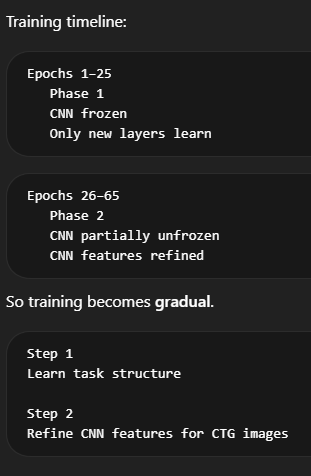

In [ ]:
def train_two_phase(model, base, X_img_tr, X_seq_tr,
                    X_img_va, X_seq_va, name):
    print(f"\n{'='*55}\nTraining: {name}")

    # Phase 1 — frozen CNN, more epochs
    print("  Phase 1: CNN frozen...")
    h1 = model.fit(
        [X_img_tr, X_seq_tr], y_tr_cat,
        validation_data=([X_img_va, X_seq_va], y_va_cat),
        epochs=25,          # more epochs than before
        batch_size=32,
        class_weight=class_weights,
        callbacks=get_callbacks(f'{name}_p1'),
        verbose=0
    )

    # Phase 2 — unfreeze top 50 layers (more than before)
    print("  Phase 2: fine-tuning top 50 ResNet layers...")
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False
    model.compile(Adam(5e-5),   # lower LR for stability
                  'categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(
        [X_img_tr, X_seq_tr], y_tr_cat,
        validation_data=([X_img_va, X_seq_va], y_va_cat),
        epochs=40,
        batch_size=16,
        class_weight=class_weights,
        callbacks=get_callbacks(f'{name}_p2'), 
        verbose=0
    )
    return h1, h2

# whar is passed from h1 to h2? the model weights after phase 1 training, which are then fine-tuned in phase 2
# where is this done? in the callbacks, we have ModelCheckpoint which saves the best weights during phase 1 training, 
# and then when we unfreeze the layers and compile the model for phase 2, we are starting with those best weights from phase 1, 
# which are then fine-tuned during phase 2 training. So the "passing" of weights from h1 to h2 is implicit in how we set up the model and callbacks.


def evaluate_model(model, X_img_te, X_seq_te, name, cmap='Blues'):
    loss, acc = model.evaluate([X_img_te, X_seq_te], y_te_cat, verbose=0)
    y_pred    = np.argmax(model.predict([X_img_te, X_seq_te], verbose=0), axis=1)
    print(f"\n{name} — Test Acc: {acc:.4f}")
    print(classification_report(y_te_seq, y_pred, target_names=label_names))
    cm = confusion_matrix(y_te_seq, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'cm_{name}.png'))
    plt.show()
    return acc, y_pred


def plot_learning_curve(h1, h2, name, color='steelblue'):
    train_acc = h1.history['accuracy']     + h2.history['accuracy']
    val_acc   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    train_loss = h1.history['loss']        + h2.history['loss']
    val_loss   = h1.history['val_loss']    + h2.history['val_loss']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(train_acc,  label='Train', color=color)
    axes[0].plot(val_acc,    label='Val',   color=color, linestyle='--')
    axes[0].axvline(len(h1.history['accuracy'])-1, color='gray',
                    linestyle=':', label='Fine-tune start')
    axes[0].set_title(f'Accuracy — {name}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train', color=color)
    axes[1].plot(val_loss,   label='Val',   color=color, linestyle='--')
    axes[1].axvline(len(h1.history['loss'])-1, color='gray',
                    linestyle=':', label='Fine-tune start')
    axes[1].set_title(f'Loss — {name}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'lc_{name}.png'))
    plt.show()


# SECTION 5 — Baseline: ResNet50 + LSTM


In [11]:
# Architecture:
#
#  Image Input (224,224,3)     Sequence Input (600,2)
#         ↓                           ↓
#     ResNet50                   LSTM(128) → return_seq=True
#     frozen                          ↓
#         ↓                      LSTM(128) → return_seq=True
#  GlobalAvgPool2D                    ↓
#         ↓                      LSTM(128) → return_seq=False
#  BatchNorm                          ↓
#         ↓                      Dense(64, relu)
#  Dense(128, relu)                   ↓
#  Dropout(0.4)                  Dropout(0.4)
#         └──────── Concat ───────────┘
#                      ↓
#               Dense(128, relu)
#               Dropout(0.3)
#               Dense(3, softmax)   ← Normal / Suspect / Pathologic

In [ ]:
def build_resnet_lstm_baseline():
    # CNN branch
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input')
    base      = ResNet50(weights='imagenet', include_top=False,
                         input_tensor=img_input)
    base.trainable = False # freeze all ResNet layers for initial training
    cnn_x = GlobalAveragePooling2D()(base.output)
    cnn_x = BatchNormalization()(cnn_x)
    cnn_x = Dense(256, activation='relu')(cnn_x)   # increased from 128
    cnn_x = Dropout(DROPOUT)(cnn_x)
    cnn_x = Dense(128, activation='relu')(cnn_x)   # extra dense layer #  
    cnn_x = Dropout(DROPOUT)(cnn_x) # dim: (128,)

    # RNN branch
    seq_input = Input(shape=(WINDOW, 2), name='seq_input')
    x = LSTM(RNN_UNITS, return_sequences=True)(seq_input)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT)(x)
    x = LSTM(RNN_UNITS, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT)(x)
    x = LSTM(RNN_UNITS)(x)
    rnn_x = Dense(128, activation='relu')(x)       
    rnn_x = Dropout(DROPOUT)(rnn_x) #dim: (128,)

    # Merge
    merged = Concatenate()([cnn_x, rnn_x]) # stacking the CNN and RNN features 
    merged = Dense(256, activation='relu')(merged)
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.2)(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model, base # what is base? the resnet50 part of the model, which we will unfreeze later for fine-tuning

tf.random.set_seed(SEED)
model_base, base_b = build_resnet_lstm_baseline()
h1_b, h2_b = train_two_phase(model_base, base_b, 
                               X_tr_img, X_tr_seq,
                               X_va_img, X_va_seq, 'Baseline')
acc_base, _ = evaluate_model(model_base, X_te_img, X_te_seq,
                              'ResNet50+LSTM_baseline', cmap='Blues')
plot_learning_curve(h1_b, h2_b, 'ResNet50+LSTM_baseline', 'steelblue')
model_base.save(os.path.join(MODEL_DIR, 'ResNet50+LSTM_baseline.keras'))
print(f"✓ Baseline saved | Test Acc: {acc_base:.4f}")


I0000 00:00:1772829901.592084      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Training: Baseline
  Phase 1: CNN frozen...


I0000 00:00:1772829924.679685      65 cuda_dnn.cc:529] Loaded cuDNN version 91002



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch: 15.
  Phase 2: fine-tuning top 50 ResNet layers...

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.

ResNet50+LSTM_baseline — Test Acc: 0.6616
              precision    recall  f1-score   support

      Normal       0.88      0.72      0.79       770
     Suspect       0.10      0.07      0.08        44
  Pathologic       0.19      0.49      0.28        99

    accuracy                           0.66       913
   macro avg       0.39      0.43      0.38       913
weighted avg       0.77      0.66      0.70       913

✓ Baseline saved | Test Acc: 0.6616


# SECTION 6 — ResNet50 + LSTM + Attention


In [13]:
# Key difference from baseline:
#   All 3 LSTM layers return sequences (return_sequences=True)
#   → output shape: (batch, 600, 128)
#
#   MultiHeadAttention(num_heads=4, key_dim=32):
#   → 4 attention heads each with key dimension 32
#   → each head learns to focus on different temporal patterns
#   → e.g. head 1 may focus on decelerations
#          head 2 may focus on variability patterns
#
#   Self-attention: query=x, key=x, value=x
#   → each timestep attends to all other timesteps
#   → output: weighted sum of all timesteps
#
#   GlobalAveragePooling1D → collapses time dimension
#
# Architecture addition:
#   LSTM(128) → return_seq=True  ← changed from baseline
#         ↓
#   MultiHeadAttention(heads=4, key_dim=32)
#         ↓
#   GlobalAvgPool1D              ← pool over attended timesteps
#         ↓
#   Dense(64)

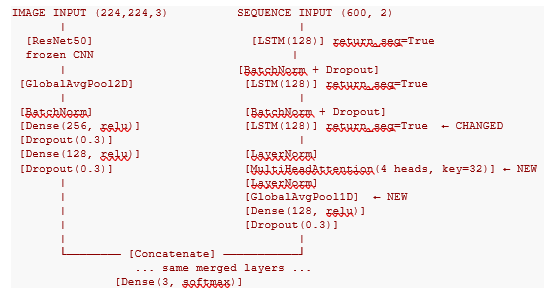

In [ ]:
def build_resnet_lstm_attention():
    # CNN branch
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input')
    base      = ResNet50(weights='imagenet', include_top=False,
                         input_tensor=img_input)
    base.trainable = False
    cnn_x = GlobalAveragePooling2D()(base.output)
    cnn_x = BatchNormalization()(cnn_x) 
    cnn_x = Dense(256, activation='relu')(cnn_x)
    cnn_x = Dropout(DROPOUT)(cnn_x)
    cnn_x = Dense(128, activation='relu')(cnn_x)
    cnn_x = Dropout(DROPOUT)(cnn_x) # dim after CNN branch: (batch, 128)

    # LSTM + Attention branch
    seq_input = Input(shape=(WINDOW, 2), name='seq_input')
    x = LSTM(RNN_UNITS, return_sequences=True)(seq_input)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT)(x)
    x = LSTM(RNN_UNITS, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT)(x)
    x = LSTM(RNN_UNITS, return_sequences=True)(x)  # keep sequences for attention # dim after LSTM: (batch, 600, 128), 600 timesteps, 128 features per timestep

    # LayerNorm before attention — improves stability
    x        = LayerNormalization()(x) # pre-attention norm 
    attn_out = MultiHeadAttention(num_heads=4, key_dim=32, # 32 what is it? The key_dim parameter in MultiHeadAttention specifies the dimensionality of the query and key vectors for each attention head. In this case, setting key_dim=32 means that each attention head will learn to project the input sequences into a 32-dimensional space for computing attention scores. This allows each head to focus on different aspects of the temporal patterns in the data, such as decelerations, variability, or other clinically relevant features in the FHR and UC signals. The choice of 32 is a common setting that balances expressiveness with computational efficiency, but it can be tuned based on the specific dataset and model performance.
                                  dropout=0.1)(x, x) # query=x, key=x, value=x → self-attention , dim after attention: (batch, 600, 128)
    attn_out = LayerNormalization()(attn_out)          # post-attention norm # dim after attention: (batch, 600, 128)
    attn_out = GlobalAveragePooling1D()(attn_out) # pool over time dimension → (batch, 128)
    rnn_x    = Dense(128, activation='relu')(attn_out)
    rnn_x    = Dropout(DROPOUT)(rnn_x) # dim after RNN branch: (batch, 128)

    # Merge
    merged = Concatenate()([cnn_x, rnn_x])
    merged = Dense(256, activation='relu')(merged)
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.2)(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model, base

tf.random.set_seed(SEED)
model_attn, base_a = build_resnet_lstm_attention()
h1_a, h2_a = train_two_phase(model_attn, base_a,
                               X_tr_img, X_tr_seq,
                               X_va_img, X_va_seq, 'Attention')
acc_attn, _ = evaluate_model(model_attn, X_te_img, X_te_seq,
                              'ResNet50+LSTM+Attention', cmap='Greens')
plot_learning_curve(h1_a, h2_a, 'ResNet50+LSTM+Attention', 'green')
model_attn.save(os.path.join(MODEL_DIR, 'ResNet50+LSTM+Attention.keras'))
print(f"✓ Attention model saved | Test Acc: {acc_attn:.4f}")


Training: Attention
  Phase 1: CNN frozen...

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.
  Phase 2: fine-tuning top 50 ResNet layers...

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.

ResNet50+LSTM+Attention — Test Acc: 0.7306
              precision    recall  f1-score   support

      Normal       0.87      0.84      0.86       770
     Suspect       0.08      0.23      0.12        44
  Pathologic       0.24      0.12      0.16        99

    accuracy                           0.73       913
   macro avg       0.40      0.40      0.38       913
weighted avg       0.77      0.73      0.74       913

✓ A

# SECTION 7 — ResNet50 + LSTM + Embedding


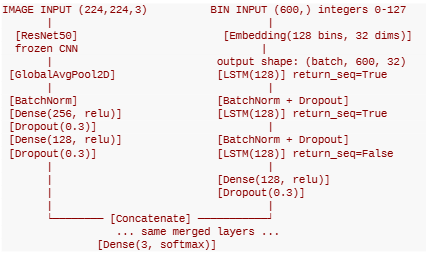

In [15]:
# Key difference: uses Embedding instead of raw FHR values
#
# Why Embedding?
#   Raw FHR values are continuous (e.g. 134.5 BPM)
#   Embedding treats them as discrete tokens (like words in NLP)
#   Each bin gets a learned dense vector representation
#   The model learns: "FHR=120 is similar to FHR=118"
#
# How discretization works:
#   FHR range (e.g. 50-200 BPM) split into 100 equal bins
#   Each FHR sample mapped to bin index 0-99
#   Embedding(100, 16): each bin → 16-dimensional vector
#
# Architecture change:
#   bin_input (600,) integers         ← discretized FHR
#         ↓
#   Embedding(100 bins, 16 dims)      ← learned lookup table
#         ↓ shape: (batch, 600, 16)
#   LSTM(128) → return_seq=True
#         ↓
#   LSTM(128) → return_seq=True
#         ↓
#   LSTM(128) → return_seq=False
#         ↓
#   Dense(64)

#  FHR Discretization + Embedding Pipeline — Full Explanation

> **Context:** This notebook section converts raw Fetal Heart Rate (FHR) signals into discrete **bin indices**, then maps those bins to **learned 32-dimensional vectors** before feeding them into sequence models (Transformer, LSTM, etc.). This two-stage pipeline — *discretize → embed* — is central to how the model understands and differentiates clinical heart rate patterns.

---

##  Key Points at a Glance

| # | Key Point | One-liner |
|---|-----------|-----------|
| 1 | **128 Equal Bins** | The full FHR range is sliced into 128 buckets of equal width |
| 2 | **Replace values with bin IDs** | Each raw BPM reading becomes an integer 0–127 |
| 3 | **Bins → 32D vectors** | An embedding table maps every bin to 32 learned numbers |
| 4 | **Similar bins → similar vectors** | The model learns medical proximity (Bin 71 ≈ Bin 72) |
| 5 | **Clinical separation** | Bradycardia bins (≈0–10) are far from tachycardia bins (≈100–127) in vector space |

---

##  Why Discretize FHR Signals?

Raw FHR values are continuous floats (e.g., `132.7`, `145.2` bpm). Deep learning architectures using **token embeddings** require discrete integer inputs. Discretization:

- Converts each timestep into a **categorical token** (bin index)
- Reduces sensitivity to minor measurement noise (~0.63 bpm per bin)
- Unlocks use of `nn.Embedding` layers for richer learned representations
- Compresses the signal into a fixed vocabulary of `N_BINS = 128` tokens

---

##  The Code

```python
N_BINS = 128   # increased from 100 — finer FHR resolution

def discretize(X_seq, n_bins=N_BINS):
    """
    Min-max binning of FHR values into discrete bin indices.
    
    Args:
        X_seq  : ndarray of shape (n_windows, timesteps, n_channels)
        n_bins : number of discrete bins (vocabulary size)
    
    Returns:
        binned : ndarray of shape (n_windows, timesteps), dtype int32
                 values in range [0, n_bins-1]
    """
    fhr     = X_seq[:, :, 0]                                          # extract FHR channel
    min_val = fhr.min()                                                # global minimum
    max_val = fhr.max()                                                # global maximum
    binned  = np.floor(
                (fhr - min_val) / (max_val - min_val + 1e-8)          # normalize to [0, ~1)
                * (n_bins - 1)                                         # scale to [0, ~127)
              )                                                        # floor → integer bin
    return binned.astype(np.int32)

X_tr_bins = discretize(X_tr_seq)   # training set
X_te_bins = discretize(X_te_seq)   # test set
X_va_bins = discretize(X_va_seq)   # validation set

print(f"Bins — shape: {X_tr_bins.shape} | range: {X_tr_bins.min()}-{X_tr_bins.max()}")
```

**Expected output:**
```
Bins — shape: (n_windows, 600) | range: 0-127
```

---

##  The Full 4-Stage Pipeline

```
RAW FHR (float bpm)
      │
      ▼  Stage 1: Divide range into 128 equal bins
BIN INDEX (int 0–127)
      │
      ▼  Stage 2: Replace each BPM value with its bin number
TOKEN SEQUENCE  [71, 71, 72, 70, 63, ...]  shape: (n_windows, 600)
      │
      ▼  Stage 3: Lookup table — each bin → 32-dimensional vector
EMBEDDING MATRIX  shape: (n_windows, 600, 32)
      │
      ▼  Stage 4: Model learns medically meaningful vector geometry
LEARNED REPRESENTATION  (similar HR → similar vectors)
```

---

##  Stage 1 — Divide the FHR Range into 128 Equal Bins

The full heart rate range (e.g., 50–200 bpm) is divided into **128 equal-width buckets**:

```
Bin 0   ≈ very low FHR    (e.g., ~50–51 bpm)    → bradycardia / severe distress
Bin 10  ≈ low FHR         (e.g., ~62 bpm)        → bradycardia threshold
Bin 32  ≈ low-normal FHR  (e.g., ~88 bpm)
Bin 64  ≈ medium FHR      (e.g., ~125 bpm)       → normal baseline
Bin 90  ≈ high-normal FHR (e.g., ~156 bpm)
Bin 110 ≈ high FHR        (e.g., ~175 bpm)       → tachycardia threshold
Bin 127 ≈ very high FHR   (e.g., ~200 bpm)       → tachycardia / severe distress
```

Each bin is approximately **~0.63 bpm wide** (assuming an 80 bpm total range).  
This is finer than the ~1 bpm resolution of standard CTG monitors — so no clinically meaningful information is lost.

---

##  Stage 2 — Replace Each FHR Value with Its Bin Number

Each raw reading becomes a single integer:

```python
# Under the hood:
bin_index = floor( (fhr_value - global_min) / (global_max - global_min) × 127 )
```

**Concrete example** (global range 100–180 bpm):

| Raw FHR (bpm) | Clinical meaning | Bin Index |
|--------------|-----------------|-----------|
| 100          | Low — near bradycardia | **0** |
| 115          | Below normal baseline | **24** |
| 134.5        | Normal fetal HR | **~71** |
| 140          | Mid-normal | **63** |
| 162          | Elevated — mild tachycardia | **~99** |
| 180          | High — tachycardia | **127** |

>  **134.5 bpm → Bin 71.** The model never sees `134.5` again — only the token `71`.

---

##  Stage 3 — Each Bin Mapped to a 32-Dimensional Learned Vector

After discretization, an **embedding layer** converts each bin index into a dense vector of 32 numbers:

```python
embedding = nn.Embedding(num_embeddings=128, embedding_dim=32)
# Input:  bin index tensor  shape (n_windows, 600)        — integers
# Output: embedded tensor   shape (n_windows, 600, 32)    — floats
X_embedded = embedding(X_tr_bins)
```

Think of it as a **lookup table** with 128 rows and 32 columns:

```
Embedding Table (128 × 32):

Bin  0  → [ 0.21, -0.84,  0.13,  0.67, ..., -0.32 ]   ← very low FHR vector
Bin  1  → [ 0.19, -0.81,  0.15,  0.65, ..., -0.30 ]
  ...
Bin 64  → [-0.05,  0.12, -0.44,  0.02, ...,  0.77 ]   ← medium FHR vector
  ...
Bin 71  → [-0.11,  0.08, -0.39,  0.05, ...,  0.81 ]
Bin 72  → [-0.10,  0.09, -0.38,  0.06, ...,  0.82 ]   ← very similar to Bin 71
  ...
Bin 127 → [ 0.88,  0.41, -0.02, -0.55, ...,  0.14 ]   ← very high FHR vector
```

These **32 numbers are not predefined** — they start random and are updated through backpropagation during training.

---

##  Stage 4 — The Model Learns Medical Proximity

This is the most powerful part. Through training, the embedding table learns a **geometry that reflects clinical meaning**:

### Adjacent bins → similar vectors (smoothness)
```
Bin 71  (134.5 bpm) → [ ... 0.81 ... ]
Bin 72  (135.1 bpm) → [ ... 0.82 ... ]   ← nearly identical (medically similar)
Bin 73  (135.7 bpm) → [ ... 0.83 ... ]

Cosine similarity(Bin71, Bin72) ≈ 0.99   → almost the same direction
```

A 0.6 bpm difference carries negligible clinical significance, and the model learns this automatically.

### Distant bins → different vectors (separation)
```
Bin 10  (~62 bpm)  → bradycardia    → [ -0.9,  0.1, -0.6, ... ]
Bin 100 (~160 bpm) → tachycardia    → [  0.8, -0.3,  0.7, ... ]

Cosine similarity(Bin10, Bin100) ≈ -0.85  → nearly opposite directions
```

Bradycardia and tachycardia are clinically opposite conditions — the model pushes their vectors far apart in 32D space.

### Clinical zones emerge naturally
```
Vector Space (conceptual 2D projection):

HIGH FHR   Bin 110–127 ●●●●●●●●●●●●●●●●●
           (tachycardia zone)
                  ↑
                  |  far apart
                  |
LOW  FHR   Bin  0–15  ●●●●●●●●●●●●●●●●●
           (bradycardia zone)

NORMAL     Bin 40–90 ●●●●●●●●●●●●●●●●●●●
           (baseline zone — dense cluster)
```

---

##  Bin-to-Clinical-Zone Mapping

| Bin Range | Approx BPM (100–180 scale) | Clinical Zone | Clinical Significance |
|-----------|---------------------------|---------------|----------------------|
| 0 – 10    | 100 – 106 bpm             | 🔴 Bradycardia | Fetal distress, hypoxia |
| 11 – 40   | 107 – 125 bpm             | 🟡 Low-normal | Below normal baseline |
| 41 – 90   | 126 – 145 bpm             | 🟢 Normal     | Healthy fetal HR range |
| 91 – 110  | 146 – 161 bpm             | 🟡 High-normal | Elevated, monitor closely |
| 111 – 127 | 162 – 180 bpm             | 🔴 Tachycardia | Fetal distress, infection |

> The model doesn't receive these labels — it **infers** this structure purely from the pattern of which bin sequences precede good vs. poor outcomes.

---

##  Step-by-Step Code Walkthrough

### Step 1 — Extract the FHR Channel

```python
fhr = X_seq[:, :, 0]   # shape: (n_windows, 600)
```
Takes channel 0 (FHR) from the 3D input. Each row = one 10-minute window of 600 readings.

### Step 2 — Find the Global Min and Max

```python
min_val = fhr.min()
max_val = fhr.max()
```
Scalar values across **all windows and all timesteps** in the split — anchors the entire scale.

### Step 3 — Normalize → Scale → Floor

```python
binned = np.floor((fhr - min_val) / (max_val - min_val + 1e-8) * (n_bins - 1))
```

| Sub-step | Formula | Output Range |
|----------|---------|-------------|
| **Normalize** | `(fhr - min) / (max - min + ε)` | `[0.0, ~1.0)` |
| **Scale** | `× 127` | `[0.0, ~127.0)` |
| **Floor** | `np.floor(...)` | `{0, 1, 2, ..., 127}` |

`1e-8` epsilon prevents division-by-zero if all values are identical.

### Step 4 — Cast to Integer

```python
return binned.astype(np.int32)
```
Ready for `nn.Embedding` lookup, autoregressive token prediction, or Transformer input.

---

##  Important Caveats

### 1. Independent Scaling Per Split (Leakage Risk)

Each split uses its own min/max — bin boundaries differ between train/test/val:

```python
#  Recommended: fit on train only, apply to all splits
train_min = X_tr_seq[:, :, 0].min()
train_max = X_tr_seq[:, :, 0].max()

def discretize_fitted(X_seq, min_val, max_val, n_bins=N_BINS):
    fhr    = X_seq[:, :, 0]
    binned = np.floor((fhr - min_val) / (max_val - min_val + 1e-8) * (n_bins - 1))
    return np.clip(binned, 0, n_bins - 1).astype(np.int32)

X_tr_bins = discretize_fitted(X_tr_seq, train_min, train_max)
X_te_bins = discretize_fitted(X_te_seq, train_min, train_max)
X_va_bins = discretize_fitted(X_va_seq, train_min, train_max)
```

### 2. Uniform Width — Not Adaptive

Bins are equally wide regardless of how many samples fall in each. Most FHR values cluster in the normal range (120–160 bpm), leaving many bins in the extremes sparse. Consider **quantile binning** for more even coverage.

### 3. Information Loss is Irreversible

Any two FHR values in the same bin become identical. At ~0.63 bpm per bin this is clinically acceptable (CTG monitors have ~1 bpm precision), but be aware the original float is unrecoverable.

---

##  Parameter Choice: N_BINS = 128

| N_BINS | bpm per bin | Vocab size | Embedding table (dim=32) |
|--------|------------|------------|--------------------------|
| 32     | ~2.5 bpm   | 32 tokens  | 4 KB                     |
| 64     | ~1.25 bpm  | 64 tokens  | 8 KB                     |
| **128**| **~0.63 bpm** | **128 tokens** | **16 KB**           |
| 256    | ~0.31 bpm  | 256 tokens | 32 KB                    |

`128` hits the sweet spot: sub-bpm resolution, tiny embedding table, power-of-2 alignment for hardware efficiency.

---

### End-to-End Summary

```
Step 1 ── Divide FHR range into 128 equal bins
          Bin 0 = very low HR (bradycardia)
          Bin 64 = medium HR  (normal baseline)
          Bin 127 = very high HR (tachycardia)

Step 2 ── Replace each BPM value with its bin number
          134.5 bpm  →  Bin 71
          Output shape: (n_windows, 600)  dtype int32

Step 3 ── Map each bin to a 32-dimensional learned vector
          nn.Embedding(128, 32)
          Bin 71  →  [-0.11, 0.08, -0.39, 0.05, ..., 0.81]
          Output shape: (n_windows, 600, 32)

Step 4 ── Model learns medically meaningful geometry
          Bin 71 ≈ Bin 72  (0.6 bpm difference → nearly identical vectors)
          Bin 10 ≠ Bin 100 (bradycardia vs tachycardia → opposite vectors)
```

The final output is a rich sequence of 32D vectors — one per second of monitoring — where **proximity in vector space reflects clinical similarity in heart rate**.

In [ ]:
N_BINS = 128   # increased from 100 — finer FHR resolution

def discretize(X_seq, n_bins=N_BINS): # simple min-max binning of FHR values    
    fhr     = X_seq[:, :, 0] # extract FHR channel (shape: n_windows, 600)
    min_val = fhr.min()
    max_val = fhr.max()
    binned  = np.floor((fhr - min_val) / (max_val - min_val + 1e-8) * (n_bins-1)) # scale to 0-(n_bins-1) and floor to get bin indices
    return binned.astype(np.int32)

X_tr_bins = discretize(X_tr_seq) # convert raw FHR to bin indices for training # DIM: (n_windows, 600) with integer values in 0-(N_BINS-1)
X_te_bins = discretize(X_te_seq) # convert raw FHR to bin indices for testing
X_va_bins = discretize(X_va_seq) # convert raw FHR to bin indices for validation
print(f"Bins — shape: {X_tr_bins.shape} | range: {X_tr_bins.min()}-{X_tr_bins.max()}") # should be (n_windows, 600) and values in 0-(N_BINS-1)

def build_resnet_lstm_embedding(): #accepts discretized bins instead of raw sequences
    # CNN branch
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input')
    base      = ResNet50(weights='imagenet', include_top=False,
                         input_tensor=img_input)
    base.trainable = False
    cnn_x = GlobalAveragePooling2D()(base.output)
    cnn_x = BatchNormalization()(cnn_x)
    cnn_x = Dense(256, activation='relu')(cnn_x)
    cnn_x = Dropout(DROPOUT)(cnn_x)
    cnn_x = Dense(128, activation='relu')(cnn_x)
    cnn_x = Dropout(DROPOUT)(cnn_x) # dim after CNN branch: (batch, 128)

    # Embedding + LSTM branch
    bin_input = Input(shape=(WINDOW,), name='bin_input') # input is now (batch, 600) of integer bin indices
    emb_x     = Embedding(input_dim=N_BINS, output_dim=32)(bin_input)  # increased output_dim to 32 for richer representations means? 
    # dim after Embedding: (batch, 600, 32)
    # Each FHR bin is now represented by a 32-dimensional vector, allowing the model to learn more complex relationships between different FHR ranges. This richer representation can help the LSTM layers capture more nuanced temporal patterns in the FHR data, potentially improving classification performance. 
    emb_x     = LSTM(RNN_UNITS, return_sequences=True)(emb_x)# dim after LSTM: (batch, 600, 128) #rnn hidden units increased to 128 for more capacity
    emb_x     = BatchNormalization()(emb_x)
    emb_x     = Dropout(DROPOUT)(emb_x)
    emb_x     = LSTM(RNN_UNITS, return_sequences=True)(emb_x) # dim after LSTM: (batch, 600, 128) 
    emb_x     = BatchNormalization()(emb_x)
    emb_x     = Dropout(DROPOUT)(emb_x)
    emb_x     = LSTM(RNN_UNITS)(emb_x) # final LSTM layer returns (batch, 128) — no return_sequences
    rnn_x     = Dense(128, activation='relu')(emb_x) # final dense layer after LSTM
    rnn_x     = Dropout(DROPOUT)(rnn_x) # dim after dense: (batch, 128)

    # Merge
    merged = Concatenate()([cnn_x, rnn_x])
    merged = Dense(256, activation='relu')(merged)
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.2)(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[img_input, bin_input], outputs=output)
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model, base

def train_two_phase_emb(model, base, name):
    print(f"\n{'='*55}\nTraining: {name}")
    print("  Phase 1: CNN frozen...")
    h1 = model.fit(
        [X_tr_img, X_tr_bins], y_tr_cat,
        validation_data=([X_va_img, X_va_bins], y_va_cat),
        epochs=25, batch_size=32,
        class_weight=class_weights,
        callbacks=get_callbacks(f'{name}_p1'),
        verbose=0
    )
    print("  Phase 2: fine-tuning...")
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False
    model.compile(Adam(5e-5), 'categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(
        [X_tr_img, X_tr_bins], y_tr_cat,
        validation_data=([X_va_img, X_va_bins], y_va_cat),
        epochs=40, batch_size=16,
        class_weight=class_weights,
        callbacks=get_callbacks(f'{name}_p2'),
        verbose=0
    )
    return h1, h2

def evaluate_model_emb(model, name):
    loss, acc = model.evaluate([X_te_img, X_te_bins], y_te_cat, verbose=0)
    y_pred    = np.argmax(model.predict([X_te_img, X_te_bins], verbose=0), axis=1)
    print(f"\n{name} — Test Acc: {acc:.4f}")
    print(classification_report(y_te_seq, y_pred, target_names=label_names))
    cm = confusion_matrix(y_te_seq, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'cm_{name}.png'))
    plt.show()
    return acc

tf.random.set_seed(SEED)
model_emb, base_e = build_resnet_lstm_embedding()
h1_e, h2_e = train_two_phase_emb(model_emb, base_e, 'Embedding')
acc_emb     = evaluate_model_emb(model_emb, 'ResNet50+LSTM+Embedding')
plot_learning_curve(h1_e, h2_e, 'ResNet50+LSTM+Embedding', 'darkorange')
model_emb.save(os.path.join(MODEL_DIR, 'ResNet50+LSTM+Embedding.keras'))
print(f"✓ Embedding model saved | Test Acc: {acc_emb:.4f}")

Bins — shape: (4246, 600) | range: 0-127

Training: Embedding
  Phase 1: CNN frozen...

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Restoring model weights from the end of the best epoch: 19.
  Phase 2: fine-tuning...

Epoch 16: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 23: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.

ResNet50+LSTM+Embedding — Test Acc: 0.7196
              precision    recall  f1-score   support

      Normal       0.86      0.82      0.84       770
     Suspect       0.17      0.09      0.12        44
  Pathologic       0.15      0.25      0.19        99

    accuracy                           0.72       913
   macro avg       0.40      0.39      0.38       913
weighted avg       0.75      0.72      0.73       913

✓ Embedding model saved | Test Acc: 0.7196


# SECTION 8 — Final Comparison


In [17]:
comparison = {
    'ResNet50+LSTM (baseline)': acc_base,
    'ResNet50+LSTM+Attention':  acc_attn,
    'ResNet50+LSTM+Embedding':  acc_emb,
}

print("\n" + "="*55)
print("FINAL COMPARISON")
print("="*55)
for name, acc in comparison.items():
    diff = acc - acc_base
    flag = '▲ improved' if diff > 0 else '▼ dropped' if diff < 0 else '= same'
    print(f"  {name:40s}  {acc:.4f}  {flag} ({diff:+.4f})")

# Bar chart
plt.figure(figsize=(10, 5))
colors = ['steelblue', 'green', 'darkorange']
bars   = plt.bar(comparison.keys(), comparison.values(), color=colors)
plt.axhline(acc_base, color='red', linestyle='--', label='Baseline')
plt.title('Baseline vs Attention vs Embedding — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.legend()
for bar, acc in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'final_comparison.png'))
plt.show()

# Learning curves together
plt.figure(figsize=(14, 5))
for h1, h2, name, color in [
    (h1_b, h2_b, 'Baseline',  'steelblue'),
    (h1_a, h2_a, 'Attention', 'green'),
    (h1_e, h2_e, 'Embedding', 'darkorange'),
]:
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.plot(val_acc, label=name, color=color)
plt.title('Val Accuracy Curves — All 3 Models')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'all_learning_curves.png'))
plt.show()

print(f"\n✓ All models saved to {MODEL_DIR}")
print(f"✓ All plots  saved to {PLOTS_DIR}")


FINAL COMPARISON
  ResNet50+LSTM (baseline)                  0.6616  = same (+0.0000)
  ResNet50+LSTM+Attention                   0.7306  ▲ improved (+0.0690)
  ResNet50+LSTM+Embedding                   0.7196  ▲ improved (+0.0581)

✓ All models saved to /kaggle/working/models
✓ All plots  saved to /kaggle/working/plots
